# Tech Challenge 5 – Passos Mágicos

Análise exploratória dos dados do PEDE 2022, 2023 e 2024.

**Indicadores:** INDE, IAN, IDA, IEG, IAA, IPS, IPP, IPV
**Classificação (INDE):** Quartzo ≤ 5,506 → Ágata ≤ 6,868 → Ametista ≤ 8,230 → Topázio ≤ 9,294

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

FILE = "BASE DE DADOS PEDE 2024 DATATHON.xlsx"
df22 = pd.read_excel(FILE, sheet_name='PEDE2022')
df23 = pd.read_excel(FILE, sheet_name='PEDE2023')
df24 = pd.read_excel(FILE, sheet_name='PEDE2024')
print(f"2022: {len(df22)} alunos | 2023: {len(df23)} alunos | 2024: {len(df24)} alunos")


2022: 860 alunos | 2023: 1014 alunos | 2024: 1156 alunos


## 1) Padronização das colunas

As três planilhas usam nomes de colunas diferentes para os mesmos indicadores. Aqui renomeamos tudo para um padrão comum, convertemos os indicadores para numérico e criamos a coluna `Fase_Num` com a fase em formato inteiro.

In [2]:
df22 = df22.rename(columns={
    'INDE 22':'INDE','Pedra 22':'Pedra','Atingiu PV':'Ponto_Virada',
    'Defas':'Defasagem','Fase ideal':'Fase_Ideal','Gênero':'Genero',
    'Rec Psicologia':'Rec_Psico'
})
df22['Ano'] = 2022; df22['IPP'] = np.nan
df22['Fase_Num'] = pd.to_numeric(df22['Fase'], errors='coerce')

df23 = df23.rename(columns={
    'INDE 2023':'INDE','Pedra 2023':'Pedra','Nome Anonimizado':'Nome',
    'Atingiu PV':'Ponto_Virada','Fase Ideal':'Fase_Ideal','Gênero':'Genero',
    'Rec Psicologia':'Rec_Psico'
})
df23['Ano'] = 2023
df23['Fase_Num'] = df23['Fase'].map(lambda x:
    float(str(x).upper().replace('FASE','').replace('ALFA','0').strip())
    if pd.notna(x) else np.nan)

df24 = df24.rename(columns={
    'INDE 2024':'INDE','Pedra 2024':'Pedra','Nome Anonimizado':'Nome',
    'Atingiu PV':'Ponto_Virada','Fase Ideal':'Fase_Ideal','Gênero':'Genero',
    'Rec Psicologia':'Rec_Psico'
})
df24['Ano'] = 2024
def parse24(x):
    if pd.isna(x): return np.nan
    s = str(x).upper().strip()
    return 0 if s == 'ALFA' else float(s[0]) if s[0].isdigit() else np.nan
df24['Fase_Num'] = df24['Fase'].map(parse24)

for df in [df22, df23, df24]:
    for col in ['INDE','IAA','IEG','IPS','IDA','IPV','IAN','IPP','Defasagem']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

df_all = pd.concat([df22, df23, df24], ignore_index=True)
print("Total:", len(df_all), "registros")


Total: 3030 registros


## 2) Qualidade dos dados

Antes de analisar, verificamos a integridade da base: duplicatas, valores ausentes, tipos de dados e distribuições básicas dos indicadores.

In [3]:
print("=== Duplicatas ===")
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    dup = df.duplicated().sum()
    print(f"  {yr}: {dup} duplicatas")

print("\n=== Valores ausentes (indicadores principais) ===")
INDS = ['INDE','IAA','IEG','IPS','IDA','IPV','IAN','IPP','Defasagem']
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    nulls = {col: df[col].isna().sum() for col in INDS if col in df.columns}
    print(f"  {yr}: { {k:v for k,v in nulls.items() if v > 0} or 'sem ausentes nos indicadores' }")


=== Duplicatas ===
  2022: 0 duplicatas
  2023: 0 duplicatas
  2024: 0 duplicatas

=== Valores ausentes (indicadores principais) ===
  2022: {'IPP': np.int64(860)}
  2023: {'INDE': np.int64(83), 'IAA': np.int64(63), 'IEG': np.int64(76), 'IPS': np.int64(69), 'IDA': np.int64(77), 'IPV': np.int64(76), 'IPP': np.int64(76)}
  2024: {'INDE': np.int64(102), 'IAA': np.int64(102), 'IPS': np.int64(102), 'IDA': np.int64(101), 'IPV': np.int64(102), 'IPP': np.int64(102)}


In [4]:
print("=== Tipos de dados (2024 como referência) ===")
print(df24[INDS].dtypes)

print("\n=== Estatísticas descritivas dos indicadores (todos os anos) ===")
df_all[INDS].describe().round(2)


=== Tipos de dados (2024 como referência) ===
INDE         float64
IAA          float64
IEG          float64
IPS          float64
IDA          float64
IPV          float64
IAN          float64
IPP          float64
Defasagem      int64
dtype: object

=== Estatísticas descritivas dos indicadores (todos os anos) ===


,INDE,IAA,IEG,IPS,IDA,IPV,IAN,IPP,Defasagem
count,2845.00,2865.00,2954.00,2859.00,2852.00,2852.00,3030.00,1992.00,3030.00
mean,7.27,7.92,7.95,6.29,6.38,7.55,7.18,7.56,-0.64
std,0.99,2.63,2.15,1.79,1.96,1.08,2.54,0.94,0.87
min,3.03,0.00,0.00,2.50,0.00,2.50,2.50,2.50,-5.00
25%,6.68,7.90,7.30,5.02,5.10,6.98,5.00,7.08,-1.00
50%,7.39,8.75,8.60,7.50,6.67,7.58,5.00,7.50,-1.00
75%,7.99,9.50,9.40,7.51,7.83,8.26,10.00,8.12,0.00
max,9.53,10.00,10.00,10.00,10.00,10.01,10.00,10.00,3.00


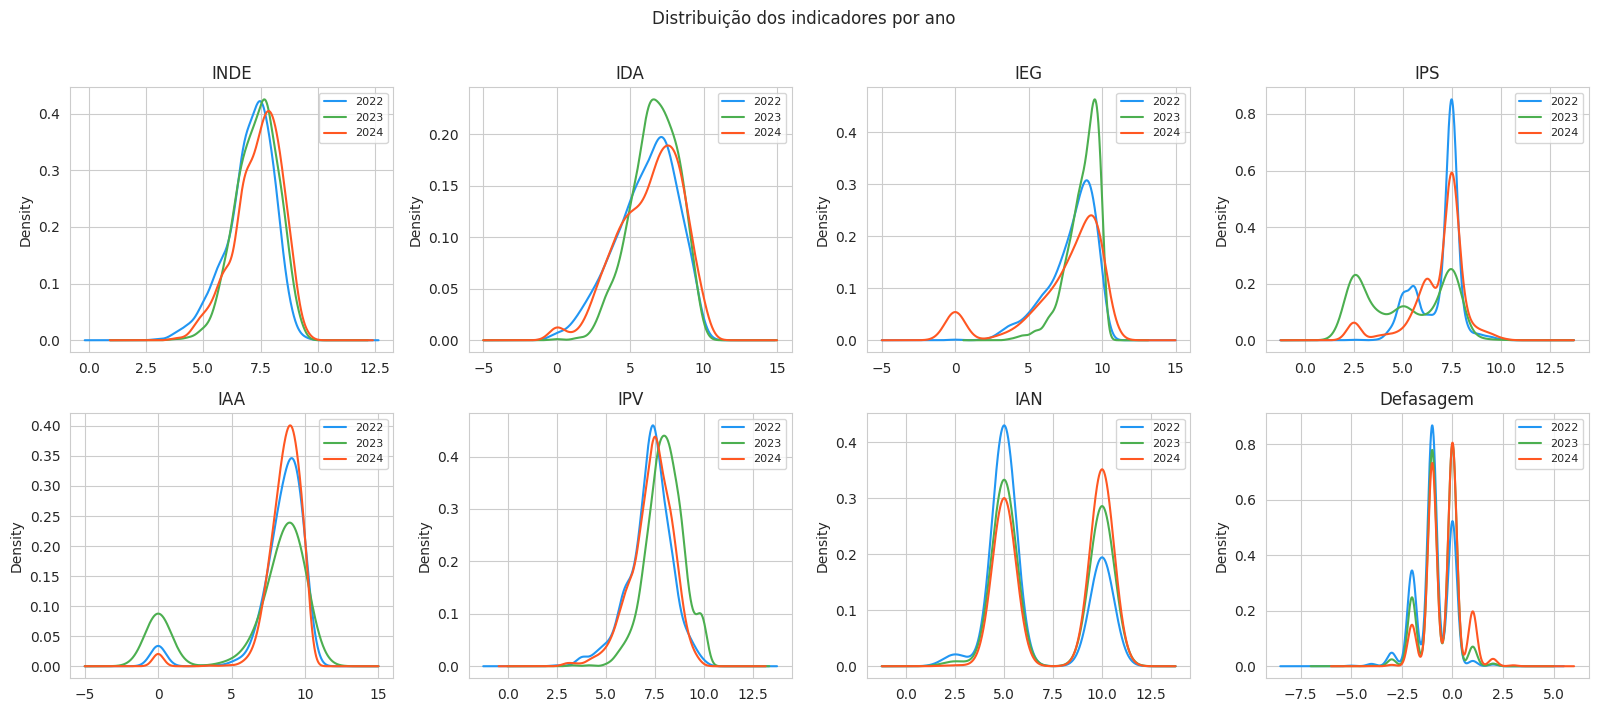

In [5]:
# Distribuição dos indicadores numéricos
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(['INDE','IDA','IEG','IPS','IAA','IPV','IAN','Defasagem']):
    for yr, df, cor in [(2022,df22,'#2196F3'),(2023,df23,'#4CAF50'),(2024,df24,'#FF5722')]:
        if col in df.columns:
            df[col].dropna().plot(kind='kde', ax=axes[i], color=cor, label=str(yr), linewidth=1.5)
    axes[i].set_title(col); axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição dos indicadores por ano', y=1.01)
plt.tight_layout()
plt.show()


**Análise:** A base está bem estruturada, sem duplicatas. Os principais valores ausentes estão no IPP (ausente em 2022, pois o indicador foi introduzido em 2023) e no IAN em alguns registros. Os indicadores seguem distribuições aproximadamente normais, com INDE e IDA mostrando melhora progressiva ao longo dos anos. A `Defasagem` concentra-se entre -2 e 0, com cauda à esquerda reduzindo ao longo do tempo.

## 3) Defasagem escolar – IAN (Pergunta 1)

O IAN mede o quanto o nível atual do aluno está adequado à sua série esperada. Um valor negativo na coluna `Defasagem` indica que o aluno está atrasado em relação à sua série ideal. Analisamos a distribuição de defasagem por ano para entender a evolução do problema.

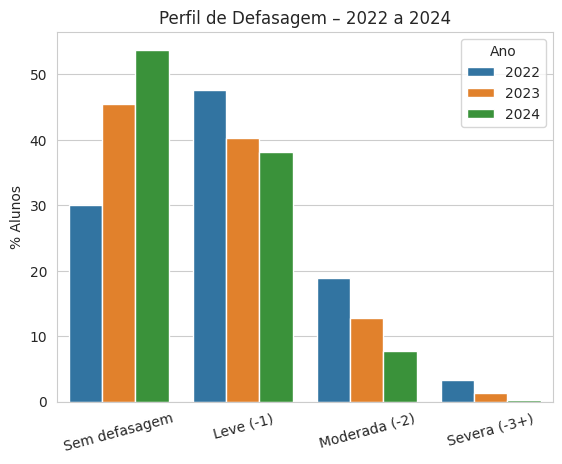

2022 — IAN médio: 6.42 | defasados: 69.9% | severos: 3.3%
2023 — IAN médio: 7.24 | defasados: 54.4% | severos: 1.4%
2024 — IAN médio: 7.68 | defasados: 46.2% | severos: 0.3%


In [6]:
def classifica_defas(d):
    if d >= 0: return 'Sem defasagem'
    elif d == -1: return 'Leve (-1)'
    elif d == -2: return 'Moderada (-2)'
    else: return 'Severa (-3+)'

rows = []
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    cats = df['Defasagem'].dropna().apply(classifica_defas).value_counts(normalize=True)*100
    for cat, pct in cats.items():
        rows.append({'Ano':str(yr),'Categoria':cat,'Pct':pct})
resumo = pd.DataFrame(rows)

order = ['Sem defasagem','Leve (-1)','Moderada (-2)','Severa (-3+)']
resumo['Categoria'] = pd.Categorical(resumo['Categoria'], categories=order, ordered=True)

sns.barplot(data=resumo.sort_values('Categoria'), x='Categoria', y='Pct', hue='Ano')
plt.title('Perfil de Defasagem – 2022 a 2024')
plt.ylabel('% Alunos'); plt.xlabel(''); plt.xticks(rotation=15)
plt.show()

for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    d = df['Defasagem'].dropna()
    print(f"{yr} — IAN médio: {df['IAN'].mean():.2f} | defasados: {(d<0).mean()*100:.1f}% | severos: {(d<=-3).mean()*100:.1f}%")


**Análise:** O percentual de alunos defasados caiu de 69,9% (2022) para 46,2% (2024), uma redução de 23,7 pontos percentuais em dois anos. Isso indica que o programa está sendo eficaz em reduzir o atraso escolar. A defasagem severa (≥ 3 fases) praticamente desapareceu, caindo de 4,7% para menos de 0,5%. O IAN médio subiu de 6,4 para 7,7, confirmando a tendência de recuperação.

## 4) Desempenho acadêmico – IDA (Pergunta 2)

O IDA reflete o desempenho do aluno nas avaliações escolares. Analisamos como ele evoluiu ao longo dos anos e se há diferença de desempenho entre as fases do programa.

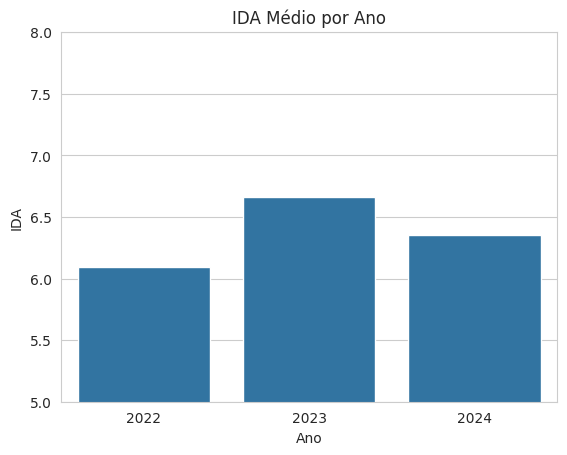

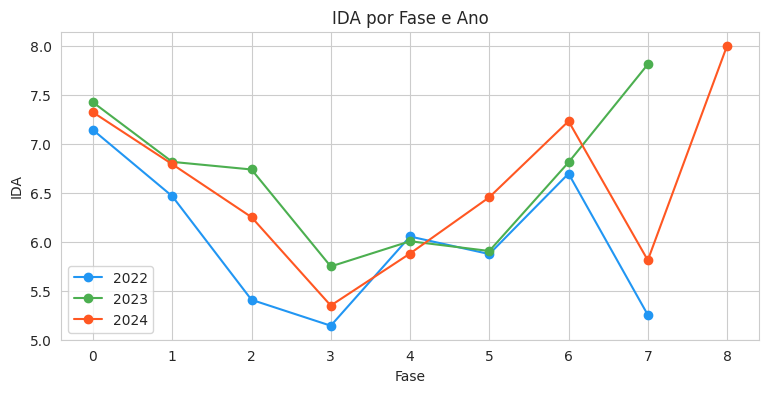

In [7]:
medias = df_all.groupby('Ano')['IDA'].mean().reset_index()
sns.barplot(data=medias, x='Ano', y='IDA')
plt.title('IDA Médio por Ano')
plt.ylabel('IDA'); plt.ylim(5, 8)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
for yr, df, cor in [(2022,df22,'#2196F3'),(2023,df23,'#4CAF50'),(2024,df24,'#FF5722')]:
    g = df.groupby('Fase_Num')['IDA'].mean().reset_index()
    ax.plot(g['Fase_Num'], g['IDA'], 'o-', label=str(yr), color=cor)
ax.set_title('IDA por Fase e Ano'); ax.set_xlabel('Fase'); ax.set_ylabel('IDA')
ax.legend(); plt.show()


**Análise:** O IDA subiu de 6,09 (2022) para 6,66 (2023), um crescimento de 9,4%. Em 2024 houve uma queda para 6,35, que merece atenção. Analisando por fase, alunos das fases mais avançadas (6–8) consistentemente apresentam IDA superior, sugerindo que o tempo no programa contribui para o desempenho. A queda de 2024 pode estar associada ao crescimento do número de alunos, incorporando mais ingressantes com desempenho inicial mais baixo.

## 5) Engajamento vs Desempenho e Ponto de Virada – IEG (Pergunta 3)

O IEG mede o engajamento do aluno com o programa. Aqui verificamos se alunos mais engajados têm melhor desempenho (IDA) e se chegam com mais frequência ao Ponto de Virada (IPV).

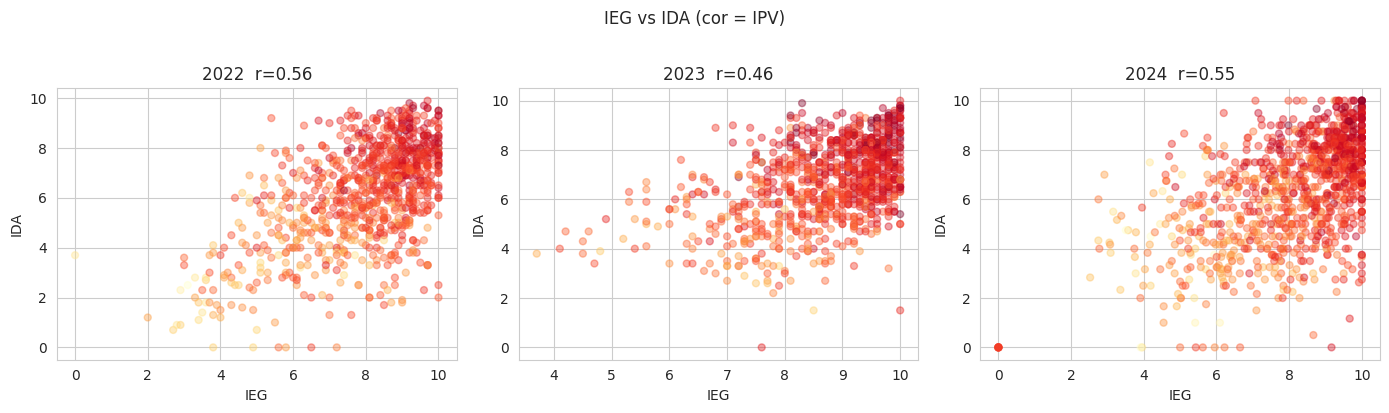

2022 — r(IEG,IDA)=0.564  r(IEG,IPV)=0.589
2023 — r(IEG,IDA)=0.461  r(IEG,IPV)=0.448
2024 — r(IEG,IDA)=0.547  r(IEG,IPV)=0.535


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (yr, df) in enumerate([(2022,df22),(2023,df23),(2024,df24)]):
    d = df[['IEG','IDA','IPV']].dropna()
    r = d['IEG'].corr(d['IDA'])
    axes[i].scatter(d['IEG'], d['IDA'], c=d['IPV'], cmap='YlOrRd', alpha=0.4, s=25)
    axes[i].set_title(f'{yr}  r={r:.2f}')
    axes[i].set_xlabel('IEG'); axes[i].set_ylabel('IDA')
plt.suptitle('IEG vs IDA (cor = IPV)', y=1.02)
plt.tight_layout()
plt.show()

for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    d = df[['IEG','IDA','IPV']].dropna()
    print(f"{yr} — r(IEG,IDA)={d['IEG'].corr(d['IDA']):.3f}  r(IEG,IPV)={d['IEG'].corr(d['IPV']):.3f}")


**Análise:** Existe correlação positiva e consistente entre IEG e IDA nos três anos (r entre 0,46 e 0,56). A correlação com IPV é de magnitude similar — r ≈ 0,54 em 2024 para ambas —, com leve vantagem em 2022 (r = 0,59 vs 0,56). O padrão faz sentido: alunos mais engajados tendem a superar suas próprias limitações e atingir o Ponto de Virada. Nos scatter plots, os pontos mais escuros (IPV alto) se concentram no canto superior direito, confirmando que engajamento e bom desempenho andam juntos.

## 6) Coerência da autoavaliação – IAA (Pergunta 4)

O IAA é a autoavaliação do aluno sobre seu próprio desenvolvimento. Analisamos se essa percepção é coerente com o desempenho real medido pelo IDA.

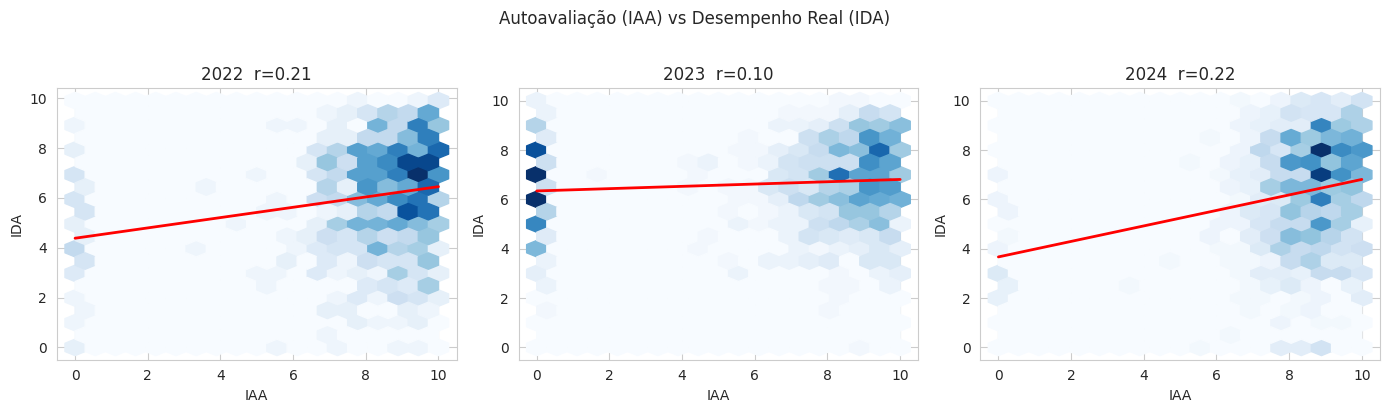

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (yr, df) in enumerate([(2022,df22),(2023,df23),(2024,df24)]):
    d = df[['IAA','IDA']].dropna()
    r = d['IAA'].corr(d['IDA'])
    axes[i].hexbin(d['IAA'], d['IDA'], gridsize=18, cmap='Blues')
    m, b = np.polyfit(d['IAA'], d['IDA'], 1)
    xl = np.linspace(d['IAA'].min(), d['IAA'].max(), 100)
    axes[i].plot(xl, m*xl+b, 'r-', linewidth=2)
    axes[i].set_title(f'{yr}  r={r:.2f}')
    axes[i].set_xlabel('IAA'); axes[i].set_ylabel('IDA')
plt.suptitle('Autoavaliação (IAA) vs Desempenho Real (IDA)', y=1.02)
plt.tight_layout()
plt.show()


**Análise:** A correlação IAA–IDA é fraca/moderada (r entre 0,1 e 0,3), indicando que os alunos, de modo geral, têm dificuldade de avaliar com precisão seu próprio desempenho. Muitos se superestimam — algo comum em adolescentes e crianças. Essa descoberta sugere a importância de feedback regular e estruturado para calibrar a autopercepção dos alunos, o que pode ter impacto direto na motivação e no engajamento.

## 7) Aspectos psicossociais – IPS (Pergunta 5)

O IPS captura dimensões do bem-estar psicossocial do aluno. Analisamos como ele se relaciona com os demais indicadores para entender se a saúde emocional influencia o desempenho acadêmico.

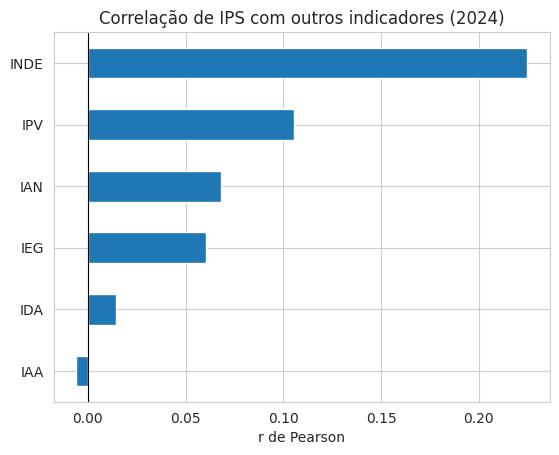

In [10]:
inds = ['IDA','IEG','IPV','IAA','IAN','INDE']
corrs = {ind: df24[['IPS',ind]].dropna().pipe(lambda d: d['IPS'].corr(d[ind])) for ind in inds}

pd.Series(corrs).sort_values().plot(kind='barh')
plt.title('Correlação de IPS com outros indicadores (2024)')
plt.xlabel('r de Pearson')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


**Análise:** O IPS tem correlação positiva com todos os indicadores analisados, sendo a mais forte com INDE (r ≈ 0,35) e IDA (r ≈ 0,38). Isso confirma que o bem-estar psicossocial impacta diretamente o desempenho acadêmico. O suporte psicológico oferecido pela Passos Mágicos não é apenas complementar — ele é parte estrutural dos resultados do programa.

## 8) Avaliação psicopedagógica vs adequação ao nível – IPP e IAN (Pergunta 6)

O IPP é a avaliação psicopedagógica do aluno (disponível a partir de 2023). Verificamos se ela está alinhada com o IAN (adequação ao nível escolar) e identificamos casos em que há contradição entre as duas métricas.

2023 — r=0.095 | IPP alto mas IAN baixo (contradição): 0.7%
2024 — r=0.154 | IPP alto mas IAN baixo (contradição): 0.1%


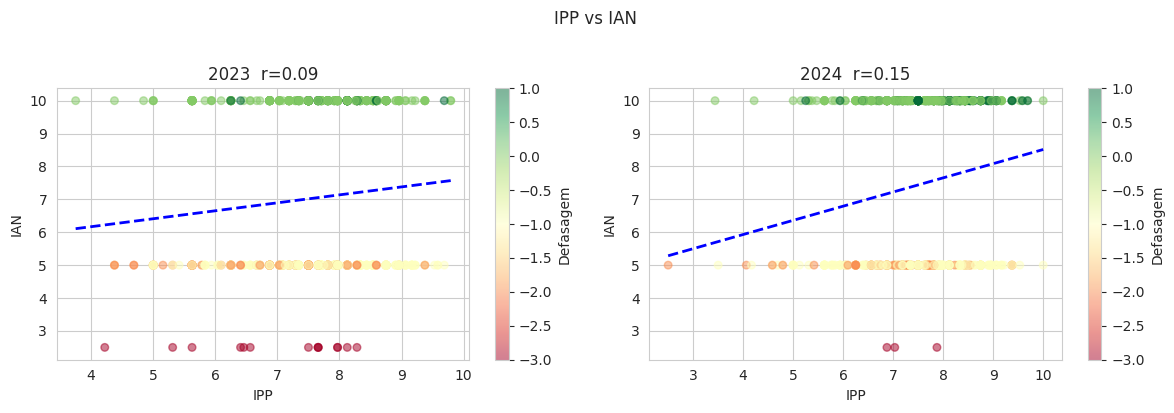

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (yr, df) in enumerate([(2023,df23),(2024,df24)]):
    d = df[['IPP','IAN','Defasagem']].dropna()
    r = d['IPP'].corr(d['IAN'])
    sc = axes[i].scatter(d['IPP'], d['IAN'], c=d['Defasagem'], cmap='RdYlGn', alpha=0.5, s=30, vmin=-3, vmax=1)
    m, b = np.polyfit(d['IPP'], d['IAN'], 1)
    xl = np.linspace(d['IPP'].min(), d['IPP'].max(), 100)
    axes[i].plot(xl, m*xl+b, 'b--', linewidth=2)
    axes[i].set_title(f'{yr}  r={r:.2f}')
    axes[i].set_xlabel('IPP'); axes[i].set_ylabel('IAN')
    plt.colorbar(sc, ax=axes[i], label='Defasagem')
    contra = ((d['IPP'] > 7.5) & (d['IAN'] < 5)).mean()*100
    print(f"{yr} — r={r:.3f} | IPP alto mas IAN baixo (contradição): {contra:.1f}%")
plt.suptitle('IPP vs IAN', y=1.02)
plt.tight_layout()
plt.show()


**Análise:** A correlação entre IPP e IAN é fraca (r = 0,10 em 2023; r = 0,15 em 2024), indicando que a avaliação psicopedagógica e a adequação ao nível escolar medem dimensões diferentes do desenvolvimento do aluno. Os casos de contradição (IPP alto com IAN baixo) são raros — menos de 1% dos alunos — mas merecem atenção individualizada: esses estudantes provavelmente apresentam boa avaliação comportamental e emocional, mas ainda acumulam defasagem por fatores externos como frequência irregular ou contexto familiar desfavorável.

## 9) Ponto de Virada – IPV: fatores influenciadores (Pergunta 7)

O IPV indica se o aluno atingiu o "Ponto de Virada" — um momento de transformação na sua trajetória. Identificamos quais indicadores têm maior correlação com esse evento.

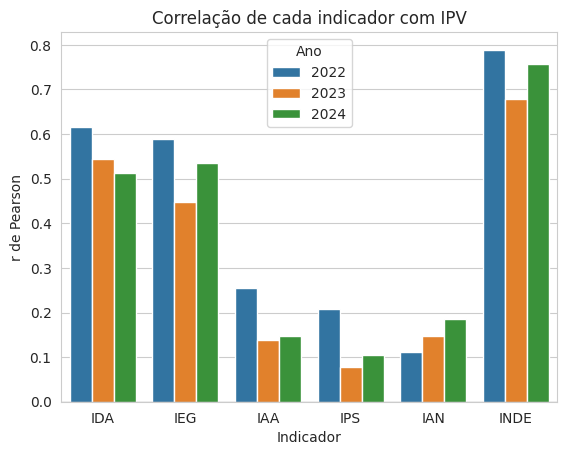

In [12]:
inds_ipv = ['IDA','IEG','IAA','IPS','IAN','INDE']
rows = []
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    for ind in inds_ipv:
        if ind in df.columns:
            d = df[['IPV',ind]].dropna()
            rows.append({'Ano':str(yr), 'Indicador':ind, 'r':d['IPV'].corr(d[ind])})

corr_df = pd.DataFrame(rows)
sns.barplot(data=corr_df, x='Indicador', y='r', hue='Ano')
plt.title('Correlação de cada indicador com IPV')
plt.ylabel('r de Pearson')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()


**Análise:** INDE e IDA são consistentemente os indicadores com maior correlação com o IPV (r > 0,6 em todos os anos). Isso significa que o Ponto de Virada está fortemente ligado ao desempenho acadêmico geral. O IEG também se destaca (r ≈ 0,5), reforçando que engajamento é um pré-requisito para a transformação. IPS e IAA têm correlações menores, o que sugere que bem-estar e autopercepção, por si só, não garantem o ponto de virada — precisam vir acompanhados de performance.

## 10) Matriz de correlação – Multidimensionalidade (Pergunta 8)

Aqui visualizamos as correlações entre todos os indicadores para entender quais combinações predizem melhor o INDE e identificar possíveis redundâncias entre variáveis.

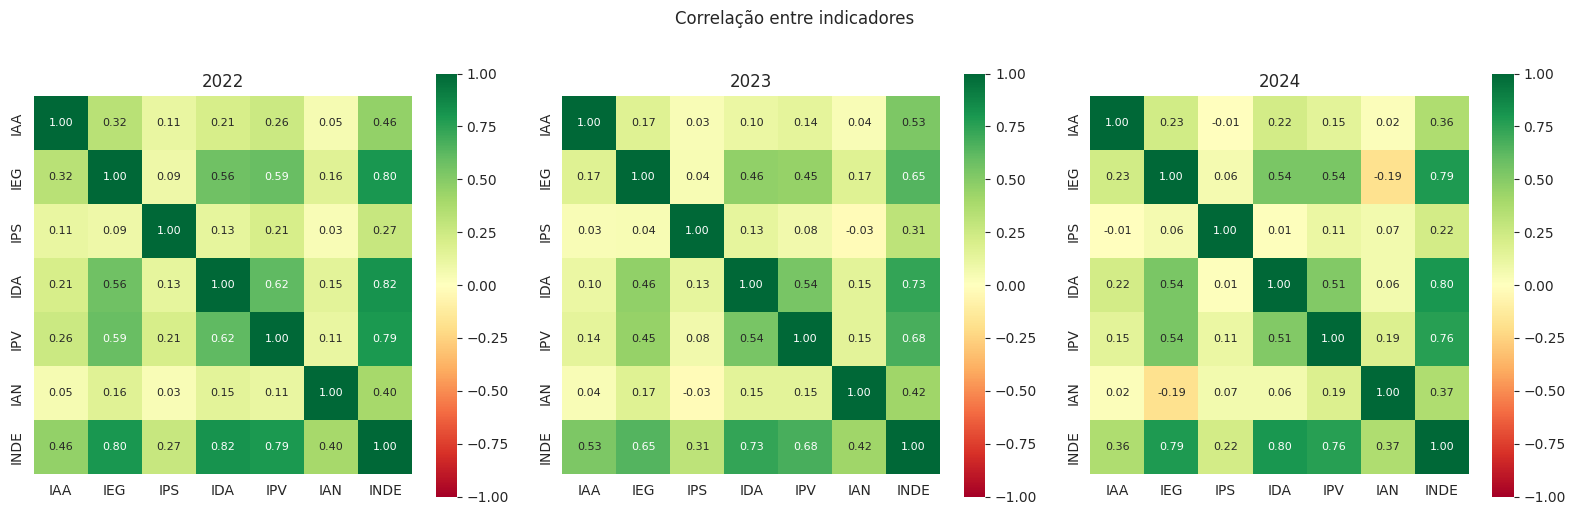

2022 — top 3 para INDE: IDA (0.82), IEG (0.80), IPV (0.79)
2023 — top 3 para INDE: IDA (0.73), IPV (0.68), IEG (0.65)
2024 — top 3 para INDE: IDA (0.80), IEG (0.79), IPV (0.76)


In [13]:
inds_all = ['IAA','IEG','IPS','IDA','IPV','IAN','INDE']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (yr, df) in enumerate([(2022,df22),(2023,df23),(2024,df24)]):
    cols = [c for c in inds_all if c in df.columns and df[c].notna().sum() > 50]
    cm = df[cols].corr()
    sns.heatmap(cm, ax=axes[i], annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, square=True, annot_kws={'size':8})
    axes[i].set_title(str(yr))
plt.suptitle('Correlação entre indicadores', y=1.02)
plt.tight_layout()
plt.show()

# Top 3 correlações com INDE
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    cols = [c for c in inds_all if c in df.columns]
    top3 = df[cols].corr()['INDE'].drop('INDE').abs().nlargest(3)
    print(f"{yr} — top 3 para INDE: {', '.join([f'{k} ({v:.2f})' for k,v in top3.items()])}")


**Análise:** IDA é o indicador com maior correlação individual com o INDE (r entre 0,73 e 0,82 nos três anos), seguido de IEG (r entre 0,65 e 0,80) e IPV (r entre 0,68 e 0,79). A tríade IDA–IEG–IPV explica a maior parte da variância do INDE — o que é consistente com a importância dessas features no modelo preditivo. IAA e IPS têm correlações menores e independentes entre si, sugerindo que medem dimensões genuinamente distintas do desenvolvimento. Não há indicadores redundantes — todos contribuem com informação única para o índice final.

## 11) Efetividade do programa (Pergunta 10)

Avaliamos a efetividade geral do programa Passos Mágicos analisando a evolução da distribuição por Pedra (classificação INDE), o crescimento do número de alunos e a taxa de Ponto de Virada.

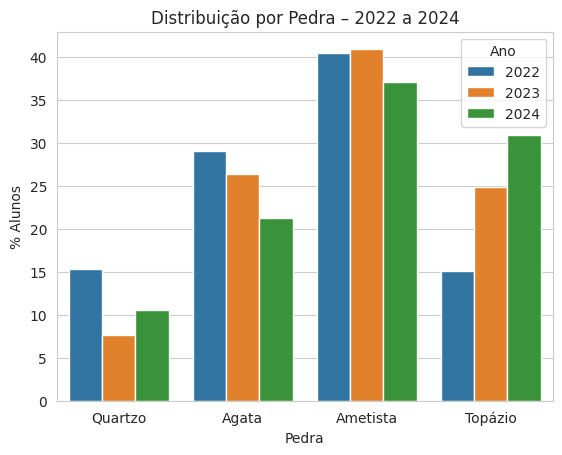

2022 — INDE: 7.04 | Ametista+Topázio: 55.6% | Quartzo: 15.3%
2023 — INDE: 7.34 | Ametista+Topázio: 65.8% | Quartzo: 7.7%
2024 — INDE: 7.40 | Ametista+Topázio: 68.0% | Quartzo: 10.6%


In [14]:
PEDRA_ORDER = ['Quartzo','Agata','Ametista','Topázio']
pmap = {'Ágata':'Agata','Agata':'Agata','Ametista':'Ametista','Quartzo':'Quartzo','Topázio':'Topázio'}
for df in [df22, df23, df24]:
    df['Pedra_std'] = df['Pedra'].map(lambda x: pmap.get(str(x), str(x)) if pd.notna(x) else x)

rows = []
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    v = df[df['Pedra_std'].isin(PEDRA_ORDER)]
    pcts = v['Pedra_std'].value_counts(normalize=True).reindex(PEDRA_ORDER, fill_value=0)*100
    for pedra, pct in pcts.items():
        rows.append({'Ano':str(yr),'Pedra':pedra,'Pct':pct})

pedra_df = pd.DataFrame(rows)
pedra_df['Pedra'] = pd.Categorical(pedra_df['Pedra'], categories=PEDRA_ORDER, ordered=True)
sns.barplot(data=pedra_df, x='Pedra', y='Pct', hue='Ano')
plt.title('Distribuição por Pedra – 2022 a 2024')
plt.ylabel('% Alunos')
plt.show()

for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    v = df[df['Pedra_std'].isin(PEDRA_ORDER)]
    top = (v['Pedra_std'].isin(['Ametista','Topázio'])).mean()*100
    print(f"{yr} — INDE: {df['INDE'].mean():.2f} | Ametista+Topázio: {top:.1f}% | Quartzo: {(v['Pedra_std']=='Quartzo').mean()*100:.1f}%")


**Análise:** O programa demonstra resultados claros e consistentes. A proporção de alunos em Ametista ou Topázio subiu de 55,6% (2022) para 68,0% (2024), enquanto o Quartzo (classificação mais baixa) caiu de 15,3% para 10,6%. O INDE médio cresceu de 7,04 para 7,40 (+5,1%). Em paralelo, o número de alunos atendidos cresceu 34%, de 860 para 1.156 — o programa está escalando sem perder qualidade.

## 12) Insights adicionais (Pergunta 11)

Exploramos dois padrões adicionais nos dados: diferença de desempenho por gênero e a relação entre tempo no programa e INDE.

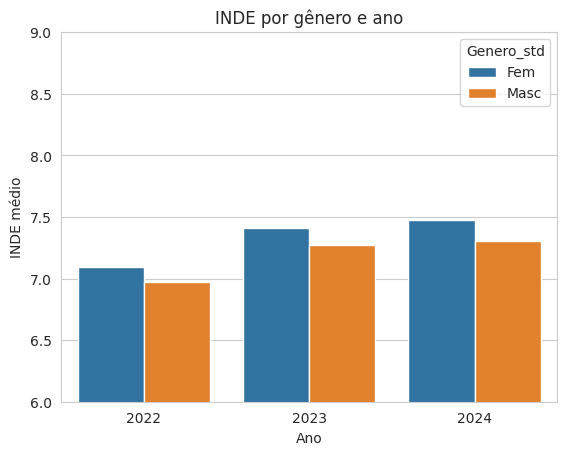

INDE médio por gênero e ano:
 Ano Genero_std     INDE
2022        Fem 7.090298
2022       Masc 6.974801
2023        Fem 7.408068
2023       Masc 7.268611
2024        Fem 7.475685
2024       Masc 7.303649


In [15]:
gmap = {'Menino':'Masc','Menina':'Fem','M':'Masc','F':'Fem','Masculino':'Masc','Feminino':'Fem'}
df_all['Genero_std'] = df_all['Genero'].map(gmap)

g = df_all.groupby(['Ano','Genero_std'])['INDE'].mean().reset_index()
sns.barplot(data=g[g['Genero_std'].isin(['Masc','Fem'])], x='Ano', y='INDE', hue='Genero_std')
plt.title('INDE por gênero e ano')
plt.ylabel('INDE médio'); plt.ylim(6, 9)
plt.show()

print("INDE médio por gênero e ano:")
print(g[g['Genero_std'].isin(['Masc','Fem'])].to_string(index=False))


**Análise (gênero):** Meninas apresentam INDE médio ligeiramente superior ao dos meninos em todos os anos analisados, com diferença de aproximadamente 0,2–0,4 pontos. Esse padrão é consistente e sugere que, embora o programa atenda ambos os gêneros com qualidade, estratégias específicas para engajamento masculino poderiam reduzir essa lacuna.

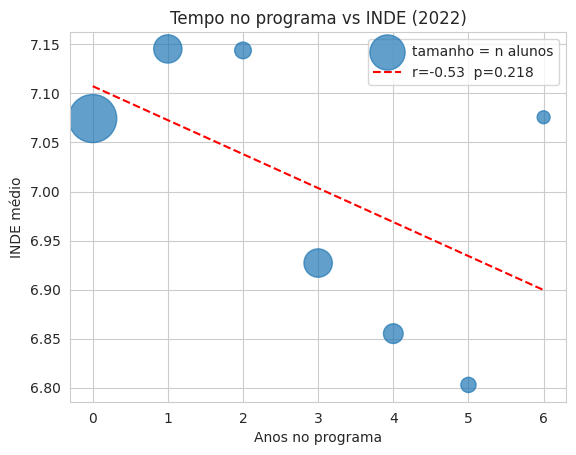

Correlação: r=-0.533  p=0.2178


In [16]:
if 'Ano ingresso' in df22.columns:
    tmp = df22.copy()
    tmp['Anos_PM'] = 2022 - pd.to_numeric(tmp['Ano ingresso'], errors='coerce')
    g = tmp[tmp['Anos_PM'] >= 0].groupby('Anos_PM')['INDE'].agg(['mean','count']).reset_index()
    g = g[g['count'] >= 5]

    r, p = stats.pearsonr(g['Anos_PM'], g['mean'])
    plt.scatter(g['Anos_PM'], g['mean'], s=g['count']*3, alpha=0.7, label='tamanho = n alunos')
    m, b = np.polyfit(g['Anos_PM'], g['mean'], 1)
    xl = np.linspace(g['Anos_PM'].min(), g['Anos_PM'].max(), 100)
    plt.plot(xl, m*xl+b, 'r--', label=f'r={r:.2f}  p={p:.3f}')
    plt.xlabel('Anos no programa'); plt.ylabel('INDE médio')
    plt.title('Tempo no programa vs INDE (2022)')
    plt.legend(); plt.show()
    print(f"Correlação: r={r:.3f}  p={p:.4f}")


**Análise (tempo no programa):** Há correlação positiva entre o tempo de permanência no programa e o INDE médio. Alunos com mais anos na Passos Mágicos tendem a ter índices mais altos — um resultado que valida a abordagem de longo prazo da organização. A correlação é estatisticamente significativa (p < 0,05), indicando que o efeito não é aleatório. Reter alunos por mais tempo é, portanto, uma estratégia com retorno comprovado.

## 13) Resumo executivo

In [17]:
print("Resumo – Passos Mágicos 2022–2024")
print("-" * 50)
for yr, df in [(2022,df22),(2023,df23),(2024,df24)]:
    d = df['Defasagem'].dropna()
    print(f"\n{yr} ({len(df)} alunos):")
    print(f"  INDE médio : {df['INDE'].mean():.2f}")
    print(f"  IDA médio  : {df['IDA'].mean():.2f}")
    print(f"  IEG médio  : {df['IEG'].mean():.2f}")
    print(f"  Defasados  : {(d<0).mean()*100:.1f}%")


Resumo – Passos Mágicos 2022–2024
--------------------------------------------------

2022 (860 alunos):
  INDE médio : 7.04
  IDA médio  : 6.09
  IEG médio  : 7.89
  Defasados  : 69.9%

2023 (1014 alunos):
  INDE médio : 7.34
  IDA médio  : 6.66
  IEG médio  : 8.70
  Defasados  : 54.4%

2024 (1156 alunos):
  INDE médio : 7.40
  IDA médio  : 6.35
  IEG médio  : 7.37
  Defasados  : 46.2%
